### Loading Packages and Data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('finalized_data.csv')

In [4]:
data.head() 

,PlayerName,position,Throws,Season,Age,IP,GS,ERA,FIP,WHIP,SO,K%,BB%,WAR,Dollars,FBv,HardHit%,Barrel%
0,Clayton Kershaw,P,L,2015,27.0,232.2,33.0,2.127507,1.990327,0.881089,301.0,0.338202,0.047191,8.552693,68.421547,93.620671,0.245387,0.033210
1,Jake Arrieta,P,R,2015,29.0,229.0,33.0,1.768559,2.347568,0.864629,236.0,0.271264,0.055172,7.033605,56.268841,94.609447,0.246552,0.022414
2,David Price,P,L,2015,29.0,220.1,32.0,2.450832,2.775046,1.075643,225.0,0.253378,0.052928,6.698485,53.587883,94.164994,0.308320,0.045677
3,Max Scherzer,P,R,2015,30.0,228.2,33.0,2.794460,2.766247,0.918367,276.0,0.307008,0.037820,6.515219,52.121754,94.167674,0.297945,0.058219
4,Dallas Keuchel,P,L,2015,27.0,232.0,33.0,2.482758,2.909456,1.017241,216.0,0.237102,0.055982,5.693698,45.549583,89.601132,0.280374,0.032710


### EDA 1 - Relationship between WAR and Dollars

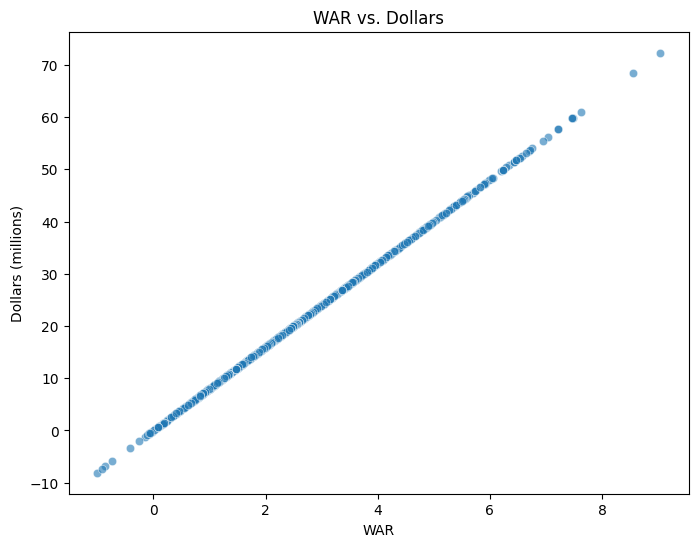

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x="WAR", y="Dollars", alpha=0.6)
plt.xlabel("WAR")
plt.ylabel("Dollars (millions)")
plt.title("WAR vs. Dollars")
plt.show()

The first plot is to look at the relationship between WAR and dollars. WAR is a metric used to assess
how valuable a player is. For a pitcher, this would use metrics such as innings pitched, strikeouts, walks, etc.
Dollars takes this WAR metric and converts into dollars to see how much money a player was worth throughout the season. 
The graph is a straight line which is expected given that dollars is generated based off WAR, so more
WAR should always lead to a higher dollar amount. Typically, Fangraphs has 1 WAR equal to 8 million dollars. 
This would seem to track based off this data as points with a value of 2 WAR sit at 16 million dollars as
2 x 8 = 16.

### EDA 2 - Relationship between FIP and WAR

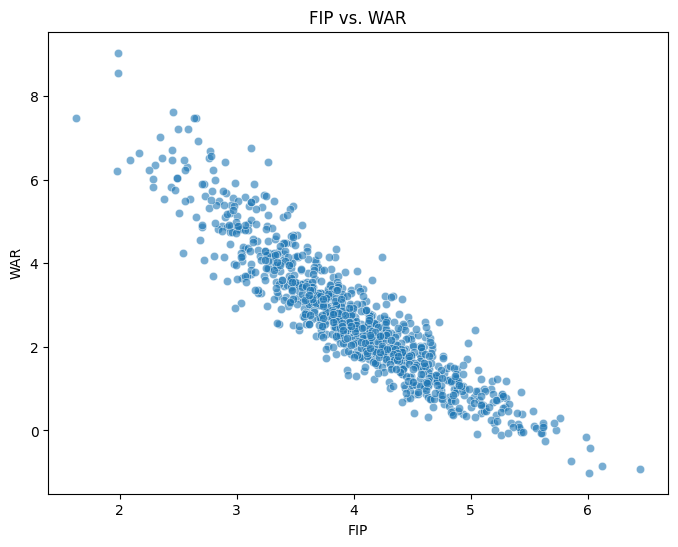

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x="FIP", y="WAR", alpha=0.6)
plt.xlabel("FIP")
plt.ylabel("WAR")
plt.title("FIP vs. WAR")
plt.show()

As previously mentioned, WAR is calculated from many stats like innings pitched and strikeouts. Another
metric used is FIP (Fielding Independent Pitching). This metric is similar to ERA, but it looks to isolate 
a pitcher's performance by looking at factors only they can control such as strikeouts, walks, home runs allowed, etc. 
Like ERA, the lower, the better for a pitcher. So while it is part of the WAR calculation, 
it is not the whole thing which is why there is a downward trend as opposed to a perfect linear line as seen with WAR and dollars. 
This makes sense as a higher FIP would indicate that a pitcher is expected to allow more runs 
when looking at only factors that they can control which would lead to them being less valuable as a result. 

### EDA 3 - Distribution of WAR

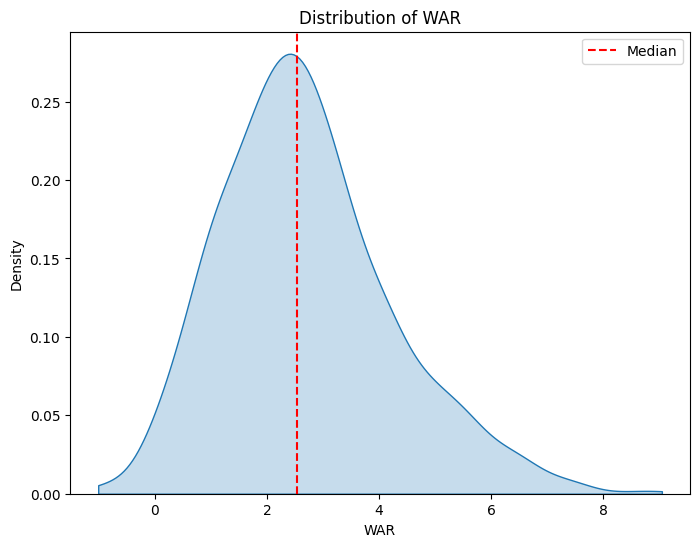

In [7]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=data, x="WAR", fill=True, cut=0)
plt.axvline(data["WAR"].median(), color="red", linestyle="--", label="Median")
plt.xlabel("WAR")
plt.ylabel("Density")
plt.title("Distribution of WAR")
plt.legend()
plt.show()

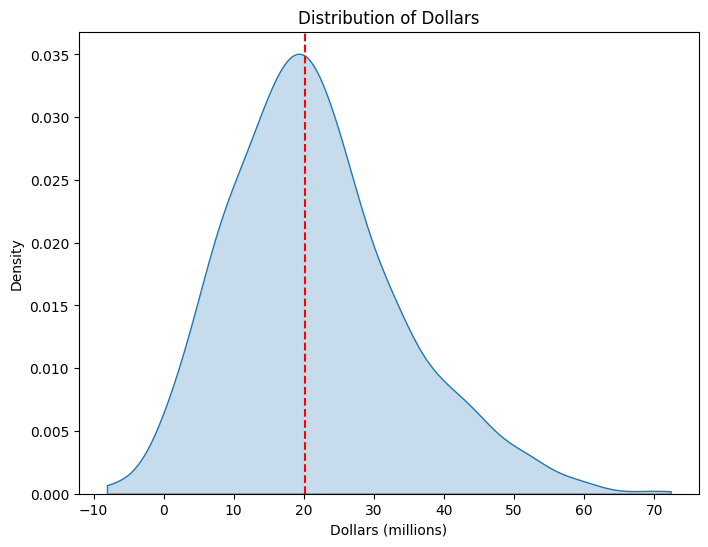

In [11]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=data, x="Dollars", fill=True, cut=0)
plt.axvline(data["Dollars"].median(), color="red", linestyle="--", label="Median")
plt.xlabel("Dollars (millions)")
plt.ylabel("Density")
plt.title("Distribution of Dollars")
plt.show()

In [9]:
round(data["WAR"].median(),2)

np.float64(2.53)

In [12]:
round(data["Dollars"].median(),2)

np.float64(20.24)

Looking at the WAR distribution, it seems to follow the standard understanding where most pitchers are between 0-4 WAR
with higher caliber pitchers being between 4-6 and pitchers over 6 tend to be Cy Young winners or finalists by the 
conclusion of the season. There are a few pitchers who have below 0 WAR. This tends to happen with pitchers who have an incredibly poor
season where a negative WAR implies that overall, they are worse than a replacement level pitcher. While it is technically 
not possible to have negative dollars, it shows that a pitcher is contributing negative value.

The dollars distirbution also has the exact same shape which lines up with the scatterplot between WAR and dollars. The medians also
match as 2.53 x 8 = 20.24. 

### EDA 4 - Relationship between Age and WAR

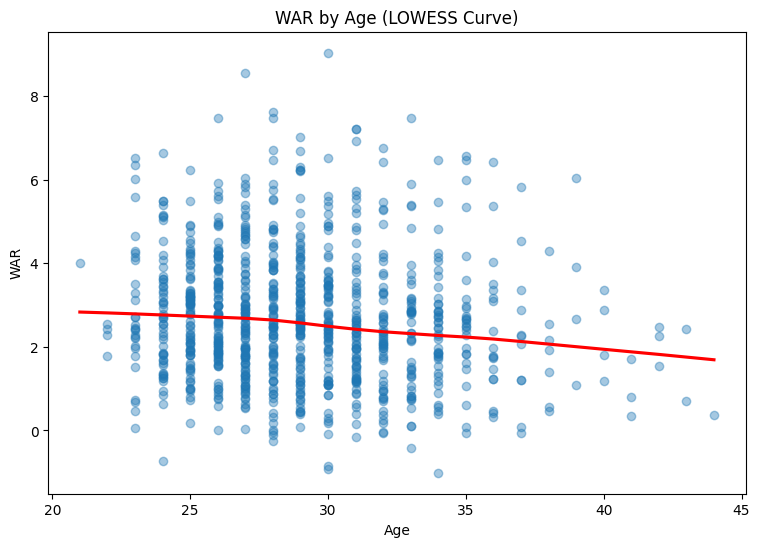

In [13]:
plt.figure(figsize=(9, 6))
sns.regplot(data=data, x="Age", y="WAR", lowess=True,
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.xlabel("Age")
plt.ylabel("WAR")
plt.title("WAR by Age (LOWESS Curve)")
plt.show()

Most aging curves tend to have a quadratic like shape where pitcher's WAR increases until about late 20s, early 30s
where the pitcher peaks and then their WAR decreases creating an upside down U shape. Here this aging curve tends to be more of a 
gradual decline. The reason for this is most likely due to the existence of survivorship bias. Since the data has 
been filtered to seasons where a pitcher started at least 25 games and pitched at least 130 IPs, many of the seasons present 
for older pitchers tend to be among the better seasons for that age group. Many of the older pitchers who may have pitched 5 or 6 games, 
performed poorly, and got cut would not be present as they were filtered out of the data. While this does exist, what is also noteworthy
is the amount of qualifying seasons significantly decreases after about 35 as there are much less points present. Even though this curve 
doesn't match the typical aging curve, it should still be noted that after 30, there is still a visible decline for WAR, but in this 
case that decline is gradual as opposed to steep. 

### EDA 5 - Correlation Heatmap

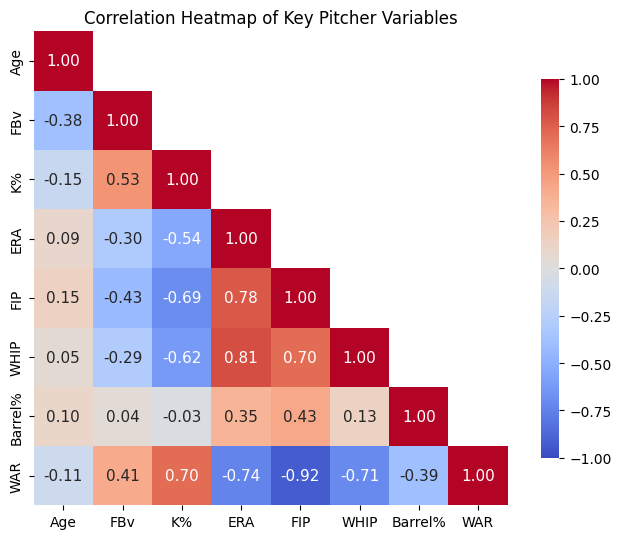

In [18]:
num = ["Age", "FBv", "K%", "ERA", "FIP", "WHIP", "Barrel%", "WAR"]

corr = data[num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", annot_kws={"size": 11},
            cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Key Pitcher Variables")
plt.tight_layout()
plt.show()

This is a correlation heatmap that looks at the correlation between variables. There are a few key things to note:

1. WAR tends to have a strong negative correlation with ERA, WHIP, and especially FIP. This makes sense as the lower all three metrics are, the better the pitcher tends to perform.
2. WAR tends to have a strong positive correlation with K% as more strikeouts tend to lead to a better performance. This is not always the case, which is why the correlation is not stronger.
3. WAR doesn't have as strong a correlation with fastball velocity as one might think. The most likely reason is that there is much more that goes into a pitcher's success especially for top-tier pitchers such as command, and the effectiveness of their other pitches.
4. WAR has a weak negative correlation with age which makes more sense when looking back at the LOWESS curve where the curve was either flat or having a slight negative slope.
5. ERA, FIP, and WHIP also seem to be strongly correlated with each other which is something to keep in mind during the modeling process, especially when running a linear regression where multicollinearity would come into play. 